<a href="https://colab.research.google.com/github/Baidunafter/NN/blob/main/%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%9610_%D0%A1%D1%80%D0%B0%D0%B2%D0%BD%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B5%D0%B9_%D0%BA%D0%BB%D0%B0%D1%81%D1%81%D0%B8%D1%84%D0%B8%D0%BA%D0%B0%D1%86%D0%B8%D0%B8_%D0%B8%D0%B7%D0%BE%D0%B1%D1%80%D0%B0%D0%B6%D0%B5%D0%BD%D0%B8%D0%B9_%D0%B8_%D1%80%D0%B0%D0%B7%D0%B2%D0%B5%D1%80%D1%82%D1%8B%D0%B2%D0%B0%D0%BD%D0%B8%D0%B5_API.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практическая работа №10. Сравнение моделей классификации изображений и развертывание API**


## **Цель работы**


Провести сравнительный анализ ранее обученных моделей классификации изображений (работы 2-5), выбрать лучшую по метрикам качества, развернуть ее в виде API и создать пользовательский интерфейс с помощью Streamlit.

---

### **Раздел 1. Подготовка и анализ моделей**


1. Загрузить выбранный датасет для классификации изображений
2. Загрузить ранее обученные модели (из практических работ 2-5)
3. Сравнить модели по метрикам качества:
   - Точность (accuracy)
   - Полнота (recall)
   - Precision
   - F1-мера
   - Время инференса (Время, затрачиваемое моделью на формирование предсказания. Измеряется путём усреднения результатов на нескольких тысячах изображений)
4. Создать сводный DataFrame с результатами всех моделей
5. Визуализировать результаты сравнения с помощью графиков
6. Построить матрицы ошибок для каждой модели
7. Выбрать лучшую модель по F1-мере
8. Сохранить лучшую модель

In [ ]:
import os
import time
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import cv2
from imutils import paths
from collections import Counter

import tensorflow as tf
from tensorflow.keras.models import load_model

from sklearn.preprocessing import LabelEncoder, LabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
)

import kagglehub

tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

In [ ]:
dataset_path = kagglehub.dataset_download("mohamedaziz15/cars-brands-in-egypt")
print("Датасет загружен:", dataset_path)

TARGET_SIZE = (64, 64)

brands_all = [d for d in os.listdir(dataset_path)
              if os.path.isdir(os.path.join(dataset_path, d))]

valid_brands = []
for brand in brands_all:
    brand_dir = os.path.join(dataset_path, brand)
    count = len(list(paths.list_images(brand_dir)))
    if count >= 1000:
        valid_brands.append((brand, count))

valid_brands.sort(key=lambda x: x[1], reverse=True)
selected_brands = [b[0] for b in valid_brands[:3]]
print(f"\nВыбранные бренды: {selected_brands}")

counts_dict = dict(valid_brands)
min_count   = min(counts_dict[b] for b in selected_brands)
print(f"Изображений на класс: {min_count}")

Датасет загружен: C:\Users\Baidunafter\.cache\kagglehub\datasets\mohamedaziz15\cars-brands-in-egypt\versions\4

Выбранные бренды: ['Suzuki', 'Toyota', 'Hundai']
Изображений на класс: 1176


In [ ]:
data   = []
labels = []

for brand in selected_brands:
    brand_dir   = os.path.join(dataset_path, brand)
    image_paths = list(paths.list_images(brand_dir))
    random.shuffle(image_paths)
    count = 0
    for img_path in image_paths:
        if count >= min_count:
            break
        image = cv2.imread(img_path)
        if image is None:
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, TARGET_SIZE)
        image = image.astype("float32") / 255.0
        data.append(image)
        labels.append(brand)
        count += 1

print(f"\nВсего изображений: {len(data)}")
print("По классам:", Counter(labels))

X = np.array(data,   dtype=np.float32)
y = np.array(labels)


Всего изображений: 3528
По классам: Counter({'Suzuki': 1176, 'Toyota': 1176, 'Hundai': 1176})


In [ ]:
le    = LabelEncoder()
y_int = le.fit_transform(y)
CLASS_NAMES = list(le.classes_)
NUM_CLASSES  = len(CLASS_NAMES)
print(f"\nКлассы: {CLASS_NAMES}")

X_train, X_test, y_int_train, y_int_test = train_test_split(
    X, y_int, test_size=0.25, random_state=42, stratify=y_int
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


X_test_flat = X_test.reshape(len(X_test), -1)

PATH = 'NN_10/Models/'

MODEL_CONFIGS = {
    "Dense (ПР2))": {
        "path"      : PATH + "final_car_model_cnn.h5",
        "input_type": "flat",
    },
    "CNN (ПР3)": {
        "path"      : PATH + "my_cnn_best_model.h5",
        "input_type": "cnn",
    },
    "VGG-like (ПР3)": {
        "path"      : PATH + "vgg_like_best_model.h5",
        "input_type": "cnn",
    },
    "Baseline (ПР4)": {
        "path"      : PATH + "model_cars_baseline_final.keras",
        "input_type": "cnn",
    },
    "BN+Dropout (ПР4)": {
        "path"      : PATH + "model_cars_bn_dropout_final.keras",
        "input_type": "cnn",
    },
}


Классы: [np.str_('Hundai'), np.str_('Suzuki'), np.str_('Toyota')]
Train: (2646, 64, 64, 3), Test: (882, 64, 64, 3)


In [ ]:
def load_model_safe(path):
    if not os.path.exists(path):
        print(f"Файл не найден: {path}")
        return None
    try:
        model = load_model(path)
        print(f"Загружена: {os.path.basename(path)}  "
              f"(параметров: {model.count_params():,})")
        return model
    except Exception as e:
        print(f"Ошибка загрузки: {e}")
        return None


def evaluate_model(model, X_input, y_true_int, n_runs=5):
    y_pred_proba = model.predict(X_input, verbose=0)
    y_pred       = np.argmax(y_pred_proba, axis=1)

    acc  = accuracy_score(y_true_int, y_pred)
    prec = precision_score(y_true_int, y_pred, average="weighted", zero_division=0)
    rec  = recall_score(y_true_int, y_pred, average="weighted", zero_division=0)
    f1   = f1_score(y_true_int, y_pred, average="weighted", zero_division=0)

    times = []
    for _ in range(n_runs):
        t0 = time.perf_counter()
        model.predict(X_input, verbose=0)
        t1 = time.perf_counter()
        times.append((t1 - t0) / len(X_input))  # сек / изображение

    inference_ms = np.mean(times) * 1000  # → мс / изображение

    return {
        "Accuracy"       : round(acc,  4),
        "Precision"      : round(prec, 4),
        "Recall"         : round(rec,  4),
        "F1-score"       : round(f1,   4),
        "Inference (ms)" : round(inference_ms, 3),
        "y_pred"         : y_pred,
        "y_pred_proba"   : y_pred_proba,
    }

In [ ]:
results = {}

for model_name, cfg in MODEL_CONFIGS.items():
    print(f"\n{model_name.replace(chr(10), ' ')}")
    model = load_model_safe(cfg["path"])
    if model is None:
        continue

    X_input = X_test_flat if cfg["input_type"] == "flat" else X_test
    metrics = evaluate_model(model, X_input, y_int_test)
    results[model_name] = metrics

    print(
        f"     Accuracy={metrics['Accuracy']:.4f}  "
        f"Precision={metrics['Precision']:.4f}  "
        f"Recall={metrics['Recall']:.4f}  "
        f"F1={metrics['F1-score']:.4f}  "
        f"Inference={metrics['Inference (ms)']:.3f} мс"
    )

    del model
    tf.keras.backend.clear_session()


Dense (ПР2))
Загружена: final_car_model_cnn.h5  (параметров: 6,456,579)


     Accuracy=0.5295  Precision=0.5006  Recall=0.5295  F1=0.4926  Inference=0.090 мс

CNN (ПР3)
Загружена: my_cnn_best_model.h5  (параметров: 2,417,699)
     Accuracy=0.9036  Precision=0.9048  Recall=0.9036  F1=0.9034  Inference=0.385 мс

VGG-like (ПР3)


Загружена: vgg_like_best_model.h5  (параметров: 39,900,995)
     Accuracy=0.9705  Precision=0.9707  Recall=0.9705  F1=0.9705  Inference=2.591 мс

Baseline (ПР4)
Загружена: model_cars_baseline_final.keras  (параметров: 683,587)
     Accuracy=0.9626  Precision=0.9637  Recall=0.9626  F1=0.9625  Inference=0.151 мс

BN+Dropout (ПР4)
Загружена: model_cars_bn_dropout_final.keras  (параметров: 684,995)
     Accuracy=0.9615  Precision=0.9620  Recall=0.9615  F1=0.9614  Inference=0.181 мс


In [ ]:
SUMMARY_COLS = ["Accuracy", "Precision", "Recall", "F1-score", "Inference (ms)"]

df_summary = pd.DataFrame(
    {name: {k: v for k, v in m.items() if k in SUMMARY_COLS}
     for name, m in results.items()}
).T.reset_index().rename(columns={"index": "Model"})

df_summary = df_summary.sort_values("F1-score", ascending=False).reset_index(drop=True)
df_summary["Model_short"] = df_summary["Model"].str.replace("\n", " ")

print(df_summary[["Model_short"] + SUMMARY_COLS].to_string(index=False))

     Model_short  Accuracy  Precision  Recall  F1-score  Inference (ms)
  VGG-like (ПР3)    0.9705     0.9707  0.9705    0.9705           2.591
  Baseline (ПР4)    0.9626     0.9637  0.9626    0.9625           0.151
BN+Dropout (ПР4)    0.9615     0.9620  0.9615    0.9614           0.181
       CNN (ПР3)    0.9036     0.9048  0.9036    0.9034           0.385
    Dense (ПР2))    0.5295     0.5006  0.5295    0.4926           0.090


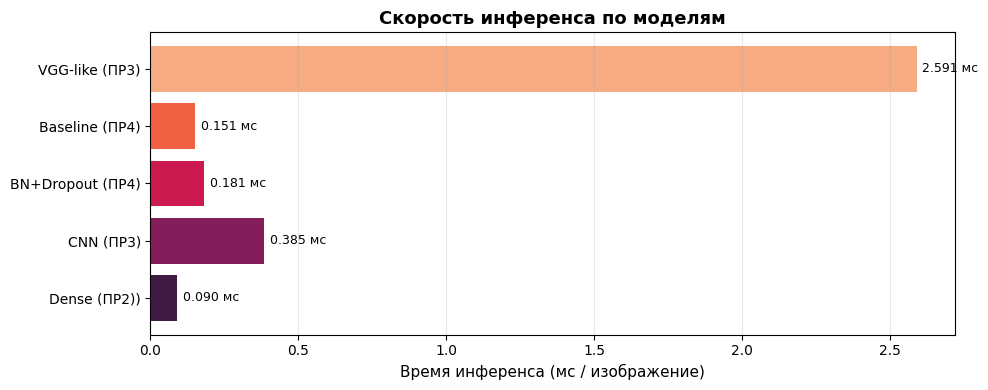

In [ ]:
fig2, ax2 = plt.subplots(figsize=(10, 4))
bars2 = ax2.barh(short_names, df_summary["Inference (ms)"],
                 color=sns.color_palette("rocket_r", len(df_summary)))
ax2.set_xlabel("Время инференса (мс / изображение)", fontsize=11)
ax2.set_title("Скорость инференса по моделям", fontsize=13, fontweight="bold")
ax2.bar_label(bars2, fmt="%.3f мс", padding=4, fontsize=9)
ax2.invert_yaxis()
ax2.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("NN_10/inference_time.png", dpi=150, bbox_inches="tight")
plt.show()

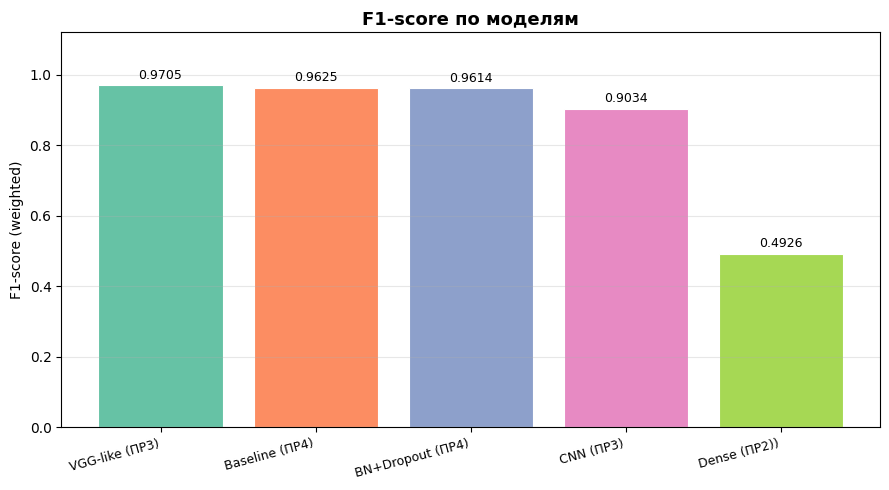

In [ ]:
fig3, ax3 = plt.subplots(figsize=(9, 5))
x = np.arange(len(df_summary))
ax3.bar(x, df_summary["F1-score"], color=palette, edgecolor="white", linewidth=0.8)
ax3.set_xticks(x)
ax3.set_xticklabels(short_names, rotation=15, ha="right", fontsize=9)
ax3.set_ylabel("F1-score (weighted)")
ax3.set_ylim(0, 1.12)
ax3.set_title("F1-score по моделям", fontsize=13, fontweight="bold")
for i, v in enumerate(df_summary["F1-score"]):
    ax3.text(i, v + 0.01, f"{v:.4f}", ha="center", va="bottom", fontsize=9)
ax3.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("NN_10/f1_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

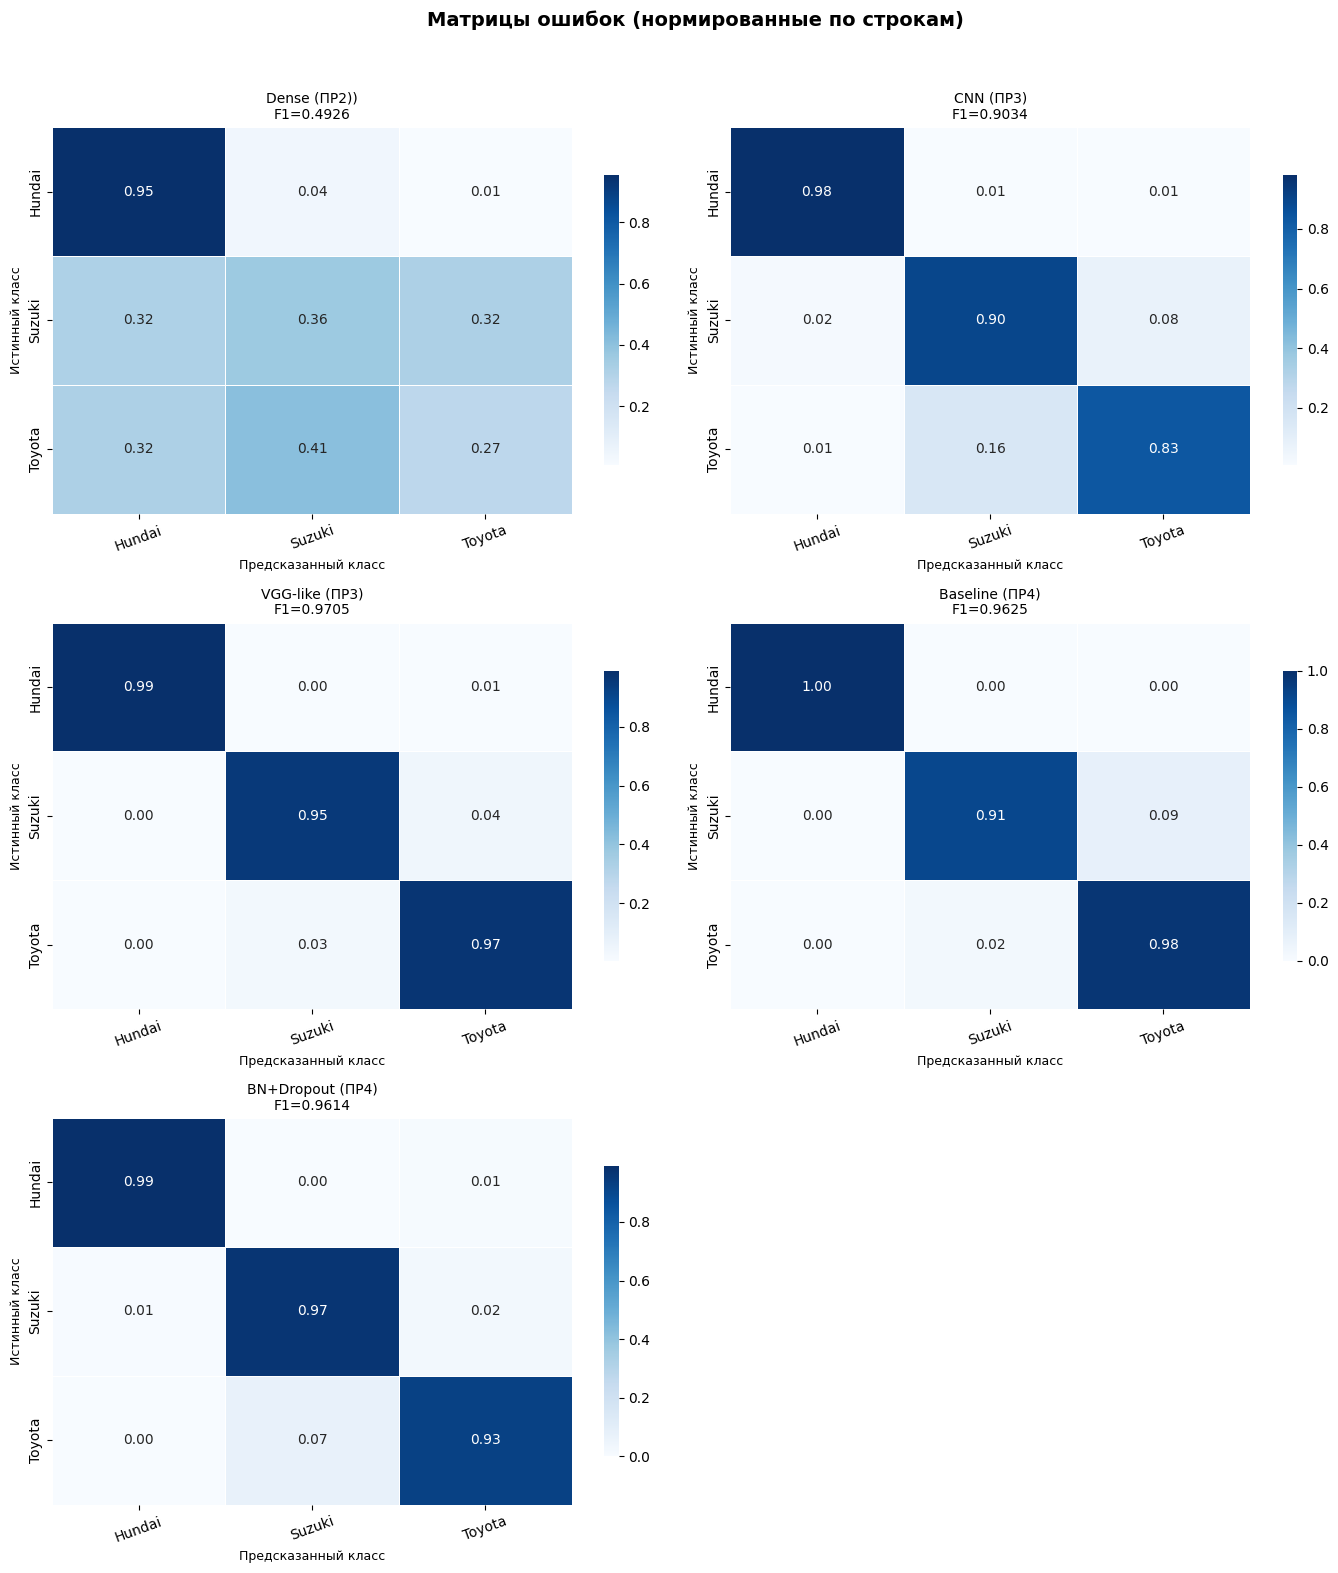

In [ ]:
n_models = len(results)
ncols    = 2
nrows    = (n_models + 1) // 2

fig_cm, axes_cm = plt.subplots(nrows, ncols,
                                figsize=(ncols * 7, nrows * 5 + 1))
fig_cm.suptitle("Матрицы ошибок (нормированные по строкам)",
                fontsize=14, fontweight="bold")
axes_cm = axes_cm.flatten()

for idx, (model_name, metrics) in enumerate(results.items()):
    cm      = confusion_matrix(y_int_test, metrics["y_pred"])
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=axes_cm[idx], linewidths=0.5, linecolor="white",
        cbar_kws={"shrink": 0.75},
    )
    short = model_name.replace("\n", " ")
    axes_cm[idx].set_title(
        f"{short}\nF1={metrics['F1-score']:.4f}", fontsize=10
    )
    axes_cm[idx].set_xlabel("Предсказанный класс", fontsize=9)
    axes_cm[idx].set_ylabel("Истинный класс", fontsize=9)
    axes_cm[idx].tick_params(axis="x", rotation=20)

for j in range(idx + 1, len(axes_cm)):
    axes_cm[j].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("NN_10/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
best_model_name = df_summary.iloc[2]["Model"]
best_f1         = df_summary.iloc[2]["F1-score"]
best_short      = df_summary.iloc[2]["Model_short"]
print(f"Лучшая модель: '{best_short}'")
print(f"F1-score = {best_f1:.4f}")

Лучшая модель: 'BN+Dropout (ПР4)'
F1-score = 0.9614


In [ ]:
BEST_MODEL_SAVE = "NN_10/best_classification_model.h5"

best_cfg   = MODEL_CONFIGS[best_model_name]
best_model = load_model(best_cfg["path"])
best_model.save(BEST_MODEL_SAVE)
print(f"Лучшая модель сохранена как: '{BEST_MODEL_SAVE}'")

Лучшая модель сохранена как: 'NN_10/best_classification_model.h5'


In [ ]:
best_X      = X_test_flat if best_cfg["input_type"] == "flat" else X_test
best_y_pred = results[best_model_name]["y_pred"]

print(f"\nClassification Report — {best_short}:")
print(classification_report(y_int_test, best_y_pred,
                             target_names=CLASS_NAMES, digits=4))


Classification Report — BN+Dropout (ПР4):
              precision    recall  f1-score   support

      Hundai     0.9932    0.9898    0.9915       294
      Suzuki     0.9283    0.9694    0.9484       294
      Toyota     0.9645    0.9252    0.9444       294

    accuracy                         0.9615       882
   macro avg     0.9620    0.9615    0.9614       882
weighted avg     0.9620    0.9615    0.9614       882



---

### **Раздел 2. Развертывание API**


1. Создать FastAPI приложение для обработки запросов с изображениями
2. Реализовать предобработку загружаемых изображений
3. Реализовать эндпоинт для классификации изображений
4. Добавить возврат предсказанного класса и вероятностей по всем классам
5. Создать файл requirements.txt с необходимыми зависимостями
6. Развернуть API на любом сервере с доступом из глобальной сети

#### **Инструкция по развёртыванию на Render.com**



**Шаги:**

1. **Репозиторий проекта:**
   - Создайте репозиторий на GitHub, содержащий файлы `main.py`, `requirements.txt`, `best_classification_model` и `scaler.pkl` (при наличии).

2. **Регистрация на Render.com:**
   - Зарегистрируйтесь на [Render.com](https://render.com/).

3. **Создание нового веб-сервиса:**
   - В панели управления Render.com создайте новый веб-сервис, связав его с вашим репозиторием.

4. **Настройка версии Python:**
   - В разделе **Environment Variables** (Переменные окружения) добавьте новую переменную:
     - **Key (Ключ):** `PYTHON_VERSION`
     - **Value (Значение):** `3.12.1`
   - Это позволит Render.com использовать указанную версию Python при сборке и запуске приложения.

5. **Настройка сервиса:**
   - Укажите команду запуска приложения: `uvicorn main:app --host 0.0.0.0 --port $PORT`.
   - Убедитесь, что в `requirements.txt` перечислены все необходимые зависимости.

6. **Развёртывание:**
   - Запустите процесс развёртывания и дождитесь его завершения.
   - После успешного развёртывания ваш API будет доступен по выделенному адресу.

#### **Инструкция по развёртыванию Hugging Face Spaces (если возникли пролемы с доступом к Render.com)**


**Шаги:**

1. **Регистрация:**
   - Зарегистрируйтесь на [huggingface.co](https://huggingface.co) (бесплатно, без карты).
   - Подтвердите e-mail.

2. **Создание нового Space:**
   - На главной странице нажмите на аватар → **New Space**.
   - Заполните поля:
     - **Space name:** `имя_проекта_backend`.
     - **License:** `mit` (или любая на ваш выбор).
     - **SDK:** выбрать **Docker** → **Blank**.
     - **Visibility:** `Public`.
     - **Hardware:** `CPU basic · 2 vCPU · 16 GB · FREE`.

3. **Push репозитория в Hugging Face:**
   - После создания Space Hugging Face даст адрес Git-репозитория вида `https://huggingface.co/spaces/ВАШ_USERNAME/california-regression`.
   - Добавьте его как удалённый репозиторий в ваш локальный проект:
   ```bash
   git remote add hf https://huggingface.co/spaces/ВАШ_USERNAME/ВАШ_РЕПОЗИТОРИЙ
   git push hf main
   ```
   - При push потребуется логин Hugging Face и **Access Token** (создаётся в Settings → Access Tokens с правом `write`).

4. **Автоматическая сборка:**
   - Hugging Face автоматически обнаружит `Dockerfile` и запустит сборку.
   - Процесс сборки занимает **5–10 минут** (установка TensorFlow — самая долгая часть).
   - Статус можно отслеживать на вкладке **Logs** в интерфейсе Space.

5. **Получение публичного URL:**
   - После успешного деплоя API доступен по адресу:
     ```
     https://ВАШ_USERNAME-ИМЯ-ПРОЕКТА.hf.space/predict
     ```
   - Этот URL работает 24/7 без усыпления, в отличие от бесплатных тарифов Render.com.

---

**Структура проекта для развёртывания на Hugging Face**

```
main.py
requirements.txt
Dockerfile
README.md
best_classification_model.h5
```

---

**Содержимое Dockerfile**


```dockerfile
# Используем официальный образ Python 3.12 (slim-версия для экономии места)
FROM python:3.12-slim

# Устанавливаем рабочую директорию внутри контейнера
WORKDIR /app

# Копируем файл зависимостей
COPY requirements.txt .

# Устанавливаем зависимости
RUN pip install --no-cache-dir --upgrade pip && \
    pip install --no-cache-dir -r requirements.txt

# Копируем все файлы проекта в контейнер
COPY . .

# Открываем порт 7860 (стандартный порт для Hugging Face Spaces)
EXPOSE 7860

# Команда запуска приложения
CMD ["uvicorn", "main:app", "--host", "0.0.0.0", "--port", "7860"]
```

---


#### **Ответ:**

**ВАША ССЫЛКА НА БЭКЕНД**
https://baidunafter-car-brand-classifier.hf.space/

---

### **Раздел 3. Создание интерфейса на Streamlit**



1. Разработать Streamlit-приложение со следующими функциями:
   - Возможность загрузки изображения пользователем
   - Возможность рисования изображения на холсте
   - Предобработка изображения перед отправкой на API
   - Отображение результатов классификации
   - Визуализация распределения вероятностей по классам
2. Развернуть Streamlit-приложение на платформе Streamlit Cloud

#### **Ответ:**

**ВАША ССЫЛКА НА ФРОНТЭНД**
https://car-brand-classifier.streamlit.app/

---

### **Раздел 4. Документация и публикация проекта**


1. Создать GitHub-репозиторий со структурой:
   - Модели (сохраненная лучшая модель)
   - API (код и зависимости)
   - Интерфейс (код Streamlit-приложения)
   - Документация (README.md)
   - Требования (requirements.txt)
2. Добавить в README.md:
   - Описание проекта и используемого датасета
   - Описание сравниваемых моделей
   - Таблицу с результатами сравнения моделей
   - Визуализации результатов
   - Инструкции по локальному развертыванию
   - Ссылки на развернутый API и Streamlit-приложение
   - Примеры использования API
3. Предоставить ссылки на:
   - GitHub-репозиторий
   - Публичный API для отправки POST-запросов
   - Streamlit-интерфейс для взаимодействия с моделью

#### **Ответ:**

**ВАША ССЫЛКА НА РЕПОЗИТОРИЙ С ПОДРОБНОЙ ДОКУМЕНТАЦИЕЙ**
https://github.com/Baidunafter/Car-Brand-Classifier

---

#### **Пример**

- **GitHub-репозиторий:** https://github.com/Alexandre77777/dpo_classification.git

- **Публичный API для отправки POST-запросов:** https://dpo-classification.onrender.com/predict/

- **Streamlit-интерфейс для взаимодействия с моделью:** https://dpo-classification.streamlit.app/
